# Decision Trees and Random Forests — from scratch
### Entropy · Information gain · 2-D boundary animation · Random forest

**Road map**

| § | Topic |
|---|---|
| §1 | Log algebra — entropy $H = -\sum p\log_2 p$ |
| §2 | Information gain and the splitting criterion |
| §3 | Building a tree: the recursive split algorithm |
| §4 | **Animated** 2-D decision boundary (surface folding) |
| §5 | Random forest — bootstrap + feature subsampling |
| §6 | Feature importance and ensemble variance |
| §7 | QM connection — measurement as classification |
| §8 | Gini impurity — the CART default |
| §9 | Out-of-bag error — validation for free |


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from dgs.decision_tree import (entropy, info_gain, best_split,
                                DecisionTree, RandomForest, accuracy)
print("ready  --  dgs.decision_tree loaded")


ready  --  dgs.decision_tree loaded


\
---
## §1  Entropy — the log algebra of uncertainty

Shannon entropy measures expected surprise in a distribution:
$$H(S) = -\sum_{k=1}^{K} p_k \log_2 p_k \qquad [\text{bits}]$$

**Log rules used everywhere:**

| Rule | Formula |
|---|---|
| Product | $\log(ab) = \log a + \log b$ |
| Power | $\log(a^n) = n\log a$ |
| Change of base | $\log_b x = \ln x / \ln b$ |
| Jensen's inequality | $f(\mathbb{E}[X]) \leq \mathbb{E}[f(X)]$ for convex $f$ |

Jensen → $H \leq \log_2 K$ (maximum when uniform), with equality iff all $p_k = 1/K$.


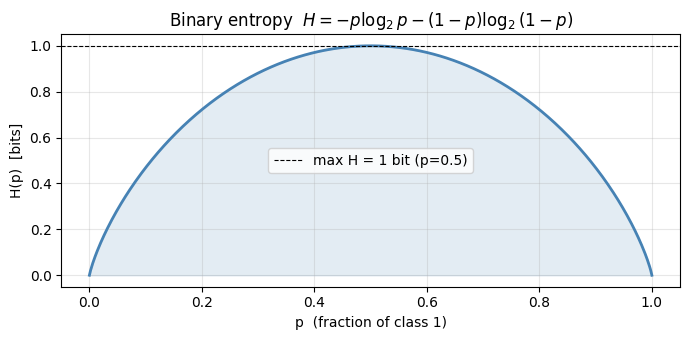

H(0.5,0.5) = 1.0000  (expect 1.0)
H(0.25,0.25,0.25,0.25) = 2.0000  (expect 2.0)
H(pure) = -0.0000  (expect 0.0)


In [2]:
\
# Plot entropy for binary class as a function of p
p = np.linspace(1e-9, 1-1e-9, 500)
H = -p*np.log2(p) - (1-p)*np.log2(1-p)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(p, H, color='steelblue', lw=2)
ax.axhline(1.0, ls='--', color='k', lw=0.8, label='max H = 1 bit (p=0.5)')
ax.fill_between(p, H, alpha=0.15, color='steelblue')
ax.set_xlabel('p  (fraction of class 1)')
ax.set_ylabel('H(p)  [bits]')
ax.set_title(r'Binary entropy  $H = -p\log_2 p - (1-p)\log_2(1-p)$')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Numeric checks
print(f"H(0.5,0.5) = {entropy(np.array([0,1])):.4f}  (expect 1.0)")
print(f"H(0.25,0.25,0.25,0.25) = {entropy(np.array([0,1,2,3])):.4f}  (expect 2.0)")
print(f"H(pure) = {entropy(np.array([0,0,0])):.4f}  (expect 0.0)")


\
---
## §2  Information gain — choosing the best split

A split divides the parent node $S$ into left $S_L$ and right $S_R$:
$$\text{IG}(S, \text{split}) = H(S) - \frac{|S_L|}{|S|}\,H(S_L) - \frac{|S_R|}{|S|}\,H(S_R)$$

Maximising IG is equivalent to minimising **weighted child entropy** — we want
children that are as pure as possible.

**Why logs?**  Because $H$ measures bits of information, and bits add under
independence:  $H(X,Y)=H(X)+H(Y)$ when $X\perp Y$.
The power rule $\log p^n = n\log p$ lets entropy scale correctly with copies.


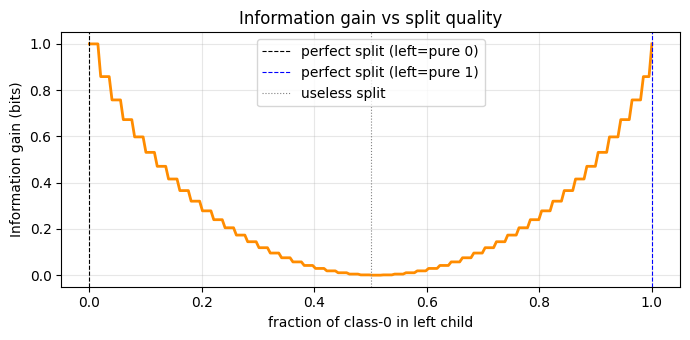

IG at alpha=0   (perfect): 1.0000  (expect 1.0)
IG at alpha=0.5 (useless): 0.0000  (expect 0.0)


In [3]:
\
# Visualise info gain as a function of split quality
# Suppose parent is 50/50 (H=1). Left child gets fraction alpha of class 0.
alphas = np.linspace(0, 1, 200)
IGs = []
for a in alphas:
    # left child: a class-0 and (1-a) class-1 (half of parent each side)
    y_parent = np.array([0]*50 + [1]*50)
    n_l = 50
    y_l = np.array([0]*int(a*n_l) + [1]*(n_l - int(a*n_l)))
    y_r = np.array([0]*(50 - int(a*n_l)) + [1]*(50 - (n_l - int(a*n_l))))
    IGs.append(info_gain(y_parent, y_l, y_r))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(alphas, IGs, color='darkorange', lw=2)
ax.axvline(0.0, ls='--', color='k', lw=0.8, label='perfect split (left=pure 0)')
ax.axvline(1.0, ls='--', color='b', lw=0.8, label='perfect split (left=pure 1)')
ax.axvline(0.5, ls=':', color='grey', lw=0.8, label='useless split')
ax.set_xlabel('fraction of class-0 in left child')
ax.set_ylabel('Information gain (bits)')
ax.set_title('Information gain vs split quality'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"IG at alpha=0   (perfect): {IGs[0]:.4f}  (expect 1.0)")
print(f"IG at alpha=0.5 (useless): {IGs[100]:.4f}  (expect 0.0)")


\
---
## §3  Building the tree — recursive binary splitting

```
function BUILD(S, depth):
    if STOP(S, depth):  return Leaf(majority_class(S))
    feat*, thresh* = argmax_{feat,thresh} IG(S, feat, thresh)
    left  = BUILD(S[x_feat <= thresh*], depth+1)
    right = BUILD(S[x_feat >  thresh*], depth+1)
    return Node(feat*, thresh*, left, right)
```

Each split is an **axis-aligned hyperplane** — it "folds" the feature space
into two half-spaces.  The 2-D boundary is a union of axis-aligned rectangles
(a **decision surface**).

**Complexity:** $O(N F \log N)$ per level, $O(N F \log^2 N)$ total for a balanced tree
(where $N$ = samples, $F$ = features).


In [4]:
\
# Build a tree on a 2-D dataset and inspect the split log
rng = np.random.default_rng(42)
N = 200
X = rng.standard_normal((N, 2))
# Two interlocked crescents
angle = np.arctan2(X[:,1], X[:,0])
y = ((np.abs(X[:,0]) + np.abs(X[:,1])) < 1.2).astype(int)
# spice it up: XOR-like quadrant pattern
y = ((X[:,0] > 0) ^ (X[:,1] > 0)).astype(int)

tree = DecisionTree(max_depth=4, min_samples_split=4, random_state=0)
tree.fit(X, y)

print(f"Tree depth: {tree.depth()}")
print(f"Splits made: {len(tree.split_log)}")
print(f"Training accuracy: {accuracy(y, tree.predict(X)):.4f}")
print()
print(f"{'#':>3}  {'feat':>5}  {'thresh':>8}  {'IG':>8}  {'depth':>6}  {'n':>5}")
for i, s in enumerate(tree.split_log):
    print(f"{i:>3}  {'x'+str(s['feat']):>5}  {s['thresh']:>8.4f}"
          f"  {s['ig']:>8.4f}  {s['depth']:>6}  {s['n_samples']:>5}")


Tree depth: 4
Splits made: 6
Training accuracy: 0.6650

  #   feat    thresh        IG   depth      n
  0     x0    1.5904    0.0186       0    200
  1     x1    1.4345    0.0196       1    186
  2     x1    1.3048    0.0203       2    175
  3     x0   -0.7253    0.0227       3    170
  4     x0    0.1875    0.8454       2     11
  5     x1    0.1297    0.8631       1     14


\
---
## §4  Animated 2-D decision boundary — "surface folding"

Each split adds one axis-aligned cut to the plane.
The animation shows splits in the order the tree discovers them (depth-first),
watching the feature space fold into purer and purer regions.


In [5]:
\
# Build dataset for animation: two spirals
def make_spirals(n=120, noise=0.25, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 4*np.pi, n)
    r = t / (4*np.pi)
    X0 = np.stack([r*np.cos(t), r*np.sin(t)], axis=1)
    X1 = np.stack([r*np.cos(t+np.pi), r*np.sin(t+np.pi)], axis=1)
    X0 += rng.standard_normal(X0.shape) * noise
    X1 += rng.standard_normal(X1.shape) * noise
    X = np.vstack([X0, X1])
    y = np.array([0]*n + [1]*n)
    return X, y

X_sp, y_sp = make_spirals(n=120, noise=0.18)

tree_anim = DecisionTree(max_depth=6, min_samples_split=3, random_state=7)
tree_anim.fit(X_sp, y_sp)
splits = tree_anim.split_log
print(f"Animating {len(splits)} splits, tree depth {tree_anim.depth()}")
print(f"Training accuracy: {accuracy(y_sp, tree_anim.predict(X_sp)):.4f}")


Animating 8 splits, tree depth 6
Training accuracy: 0.6333


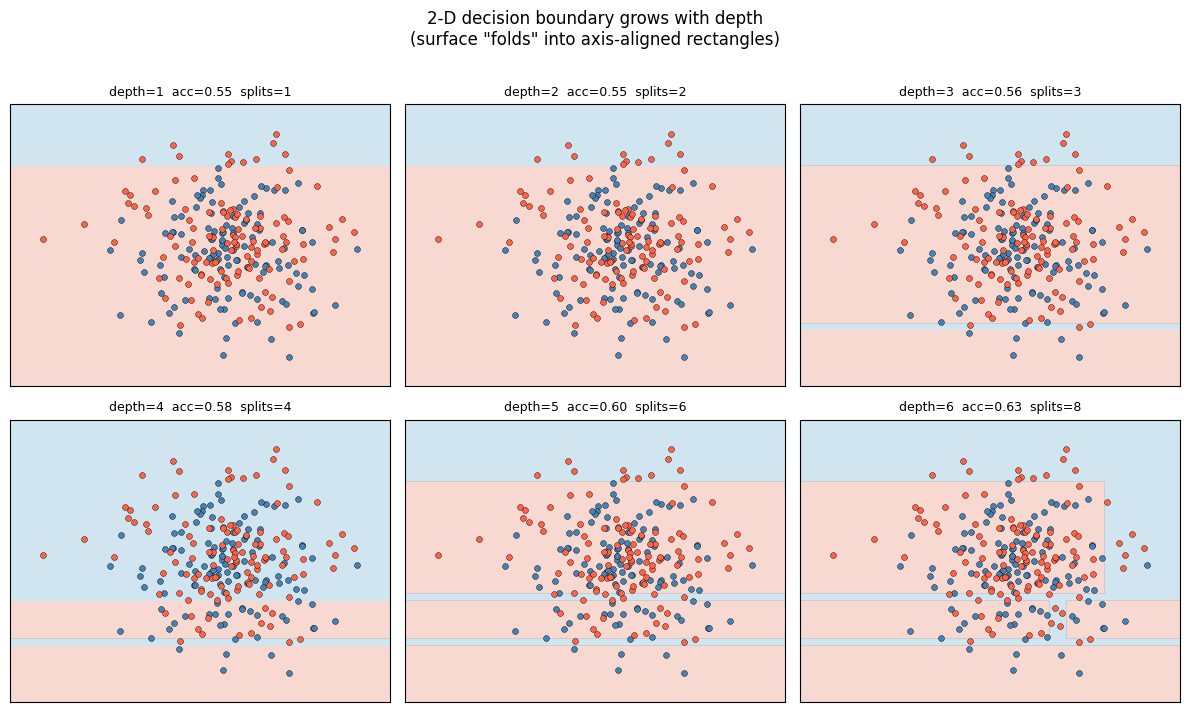

In [6]:
\
# Draw decision boundary helper
def draw_boundary(ax, tree, X, y, title="", alpha=0.3):
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = tree.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=alpha, cmap='RdBu', levels=[-0.5,0.5,1.5])
    ax.scatter(X[y==0,0], X[y==0,1], c='steelblue', s=18, edgecolors='k', lw=0.3)
    ax.scatter(X[y==1,0], X[y==1,1], c='tomato',    s=18, edgecolors='k', lw=0.3)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# Static: snapshots at depths 1,2,3,4,5,6
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, d in zip(axes.ravel(), range(1, 7)):
    t = DecisionTree(max_depth=d, min_samples_split=3, random_state=7)
    t.fit(X_sp, y_sp)
    acc = accuracy(y_sp, t.predict(X_sp))
    draw_boundary(ax, t, X_sp, y_sp,
                  title=f'depth={d}  acc={acc:.2f}  splits={len(t.split_log)}')
fig.suptitle('2-D decision boundary grows with depth\n(surface "folds" into axis-aligned rectangles)', y=1.01)
plt.tight_layout(); plt.show()


saved animation -> ..\notebooks\decision_boundary_anim.gif


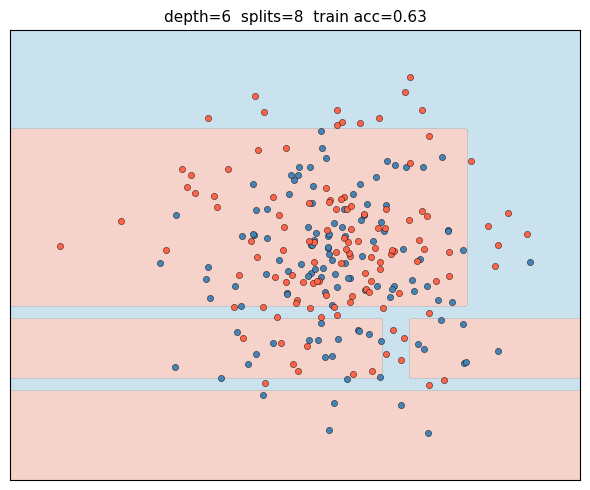

In [7]:
\
# Animation: add one split at a time
fig_a, ax_a = plt.subplots(figsize=(6, 5))

x_min, x_max = X_sp[:,0].min()-0.3, X_sp[:,0].max()+0.3
y_min_p, y_max_p = X_sp[:,1].min()-0.3, X_sp[:,1].max()+0.3

def animate(frame):
    ax_a.clear()
    d = max(1, frame + 1)
    t = DecisionTree(max_depth=min(d, 6), min_samples_split=3, random_state=7)
    t.fit(X_sp, y_sp)
    acc = accuracy(y_sp, t.predict(X_sp))
    n_splits = len(t.split_log)

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150),
                          np.linspace(y_min_p, y_max_p, 150))
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax_a.contourf(xx, yy, Z, alpha=0.35, cmap='RdBu', levels=[-0.5,0.5,1.5])
    ax_a.scatter(X_sp[y_sp==0,0], X_sp[y_sp==0,1],
                 c='steelblue', s=20, edgecolors='k', lw=0.3, zorder=3)
    ax_a.scatter(X_sp[y_sp==1,0], X_sp[y_sp==1,1],
                 c='tomato', s=20, edgecolors='k', lw=0.3, zorder=3)
    ax_a.set_xlim(x_min, x_max); ax_a.set_ylim(y_min_p, y_max_p)
    ax_a.set_title(f'depth={min(d,6)}  splits={n_splits}  train acc={acc:.2f}',
                   fontsize=11)
    ax_a.set_xticks([]); ax_a.set_yticks([])

anim = FuncAnimation(fig_a, animate, frames=7, interval=700, repeat=True)
out_gif = pathlib.Path('../notebooks/decision_boundary_anim.gif')
try:
    anim.save(str(out_gif), writer=PillowWriter(fps=1.4))
    print(f"saved animation -> {out_gif}")
except Exception as e:
    print(f"save failed ({e}); showing inline")
plt.tight_layout(); plt.show()


\
---
## §5  Random forest — bias-variance tradeoff

A single deep tree has **low bias, high variance** — it memorises the training set.
Random forest reduces variance by averaging $T$ trees, each trained on:
1. A **bootstrap sample** (n draws with replacement)
2. A **random feature subset** of size $\lfloor\sqrt{F}\rfloor$ at each split

For independent trees with equal variance $\sigma^2$ and pairwise correlation $\rho$:
$$\text{Var}(\bar{\hat{y}}) = \rho\sigma^2 + \frac{1-\rho}{T}\sigma^2 \xrightarrow{T\to\infty} \rho\sigma^2$$

Feature subsampling reduces $\rho$ — trees disagree on which feature to split,
so their errors cancel better when averaged.


In [8]:
\
# Train random forest and compare to single tree
rng = np.random.default_rng(42)
N = 400
X_rf = rng.standard_normal((N, 6))
# Labels: complex nonlinear boundary
y_rf = ((X_rf[:,0]**2 + X_rf[:,1]**2 < 1.2) |
         (X_rf[:,2] > 0.8)).astype(int)

split = 320
X_tr, y_tr = X_rf[:split], y_rf[:split]
X_te, y_te = X_rf[split:], y_rf[split:]

single = DecisionTree(max_depth=8, random_state=0)
single.fit(X_tr, y_tr)

rf = RandomForest(n_estimators=80, max_depth=8, random_state=1)
rf.fit(X_tr, y_tr)

print(f"Single tree  train={accuracy(y_tr,single.predict(X_tr)):.4f}  "
      f"test={accuracy(y_te,single.predict(X_te)):.4f}")
print(f"Random forest train={accuracy(y_tr,rf.predict(X_tr)):.4f}  "
      f"test={accuracy(y_te,rf.predict(X_te)):.4f}")


Single tree  train=1.0000  test=0.9125
Random forest train=0.9938  test=0.9750


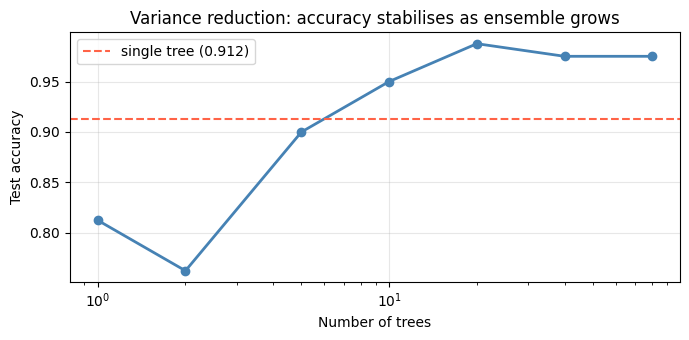

In [9]:
\
# Accuracy vs number of trees
n_trees_range = [1, 2, 5, 10, 20, 40, 80]
test_accs = []
for nt in n_trees_range:
    rf_t = RandomForest(n_estimators=nt, max_depth=8, random_state=3)
    rf_t.fit(X_tr, y_tr)
    test_accs.append(accuracy(y_te, rf_t.predict(X_te)))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogx(n_trees_range, test_accs, 'o-', color='steelblue', lw=2)
ax.axhline(accuracy(y_te, single.predict(X_te)), ls='--', color='tomato',
           label=f'single tree ({accuracy(y_te,single.predict(X_te)):.3f})')
ax.set_xlabel('Number of trees'); ax.set_ylabel('Test accuracy')
ax.set_title('Variance reduction: accuracy stabilises as ensemble grows')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


\
---
## §6  Feature importance — mean decrease in impurity

For each split in each tree, record:
$$\Delta H_\text{node} = \text{IG} \times n_\text{node}$$
Sum over all nodes and trees, normalise → **mean decrease in impurity (MDI)**.

Features that drive large IG on large nodes matter most.
Log is implicit: IG uses $H$, which uses $\log_2$.


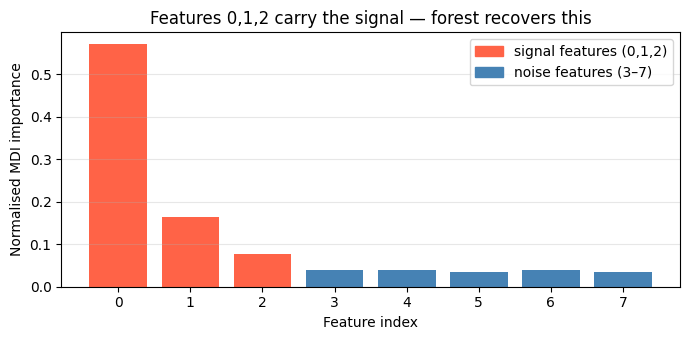

Importance vector: [0.57  0.164 0.077 0.04  0.04  0.036 0.04  0.034]


In [10]:
\
# Feature importance on known-signal data
rng = np.random.default_rng(9)
N = 500
X_imp = rng.standard_normal((N, 8))
# Only features 0,1,2 matter
y_imp = (X_imp[:,0] + 0.5*X_imp[:,1] - 0.3*X_imp[:,2] > 0).astype(int)

rf_imp = RandomForest(n_estimators=60, max_depth=6, random_state=0)
rf_imp.fit(X_imp, y_imp)
imp = rf_imp.feature_importances(X_imp, y_imp)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['tomato']*3 + ['steelblue']*5
ax.bar(range(8), imp, color=colors)
ax.set_xlabel('Feature index')
ax.set_ylabel('Normalised MDI importance')
ax.set_title('Features 0,1,2 carry the signal — forest recovers this')
ax.set_xticks(range(8))
red = mpatches.Patch(color='tomato', label='signal features (0,1,2)')
blue = mpatches.Patch(color='steelblue', label='noise features (3–7)')
ax.legend(handles=[red, blue]); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print("Importance vector:", np.round(imp, 3))


\
---
## §7  QM connection — measurement as classification

| Decision tree | Quantum mechanics |
|---|---|
| Feature space $\mathbb{R}^F$ | Hilbert space $\mathcal{H}$ |
| Split on $x_i \leq \theta$ | Projection $\hat{P}_\theta$ |
| Entropy $H = -\sum p\log p$ | Von Neumann entropy $S = -\text{Tr}(\rho\log\rho)$ |
| Information gain | Entropy decrease after measurement |
| Pure leaf node | Pure quantum state (density matrix rank 1) |
| Mixed node (entropy > 0) | Mixed state $\rho = \sum p_k|\psi_k\rangle\langle\psi_k|$ |
| Forest average | Decoherence / ensemble average |

**Von Neumann entropy** of a density matrix $\rho$ (eigenvalues $\lambda_k$):
$$S(\rho) = -\text{Tr}(\rho\ln\rho) = -\sum_k \lambda_k \ln\lambda_k$$
This is Shannon entropy applied to the eigenvalue spectrum.
Maximally mixed state $\rho = I/d$: $S = \ln d$ (maximum).
Pure state $\rho = |\psi\rangle\langle\psi|$: $S = 0$ (like a pure leaf).


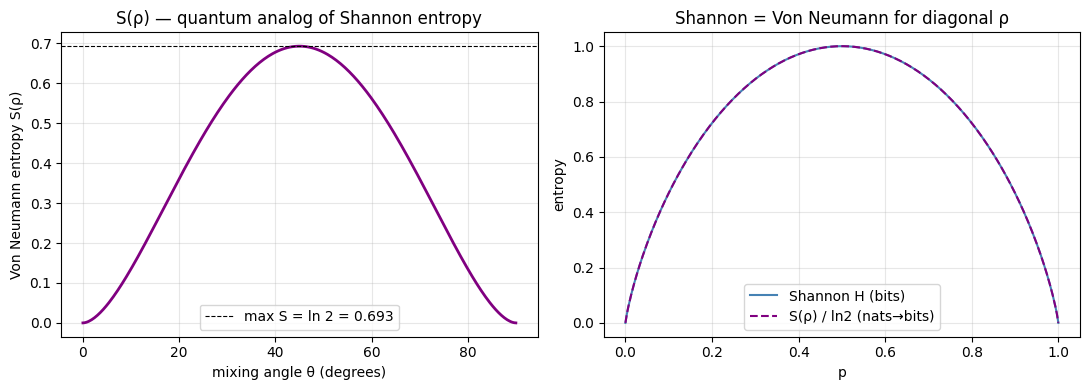

Key identity: when rho is diagonal, S(rho) = classical Shannon H
=> Decision tree entropy IS quantum entropy for diagonal density matrices


In [11]:
\
# Von Neumann entropy of a 2x2 density matrix parameterised by mixing angle
# rho(theta) = cos^2(theta)|0><0| + sin^2(theta)|1><1|
thetas = np.linspace(0, np.pi/2, 300)
S_vn = []
for th in thetas:
    lam0 = np.cos(th)**2
    lam1 = np.sin(th)**2
    lams = np.array([lam0, lam1])
    lams = lams[lams > 1e-12]
    S_vn.append(-np.sum(lams * np.log(lams)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(np.degrees(thetas), S_vn, color='purple', lw=2)
ax1.axhline(np.log(2), ls='--', color='k', lw=0.8,
            label=f'max S = ln 2 = {np.log(2):.3f}')
ax1.set_xlabel('mixing angle θ (degrees)')
ax1.set_ylabel('Von Neumann entropy S(ρ)')
ax1.set_title('S(ρ) — quantum analog of Shannon entropy')
ax1.legend(); ax1.grid(alpha=0.3)

# Compare: Shannon H (bits) vs von Neumann S (nats)
p_arr = np.linspace(1e-9, 1-1e-9, 300)
H_sh  = -p_arr*np.log2(p_arr) - (1-p_arr)*np.log2(1-p_arr)
H_vn  = -p_arr*np.log(p_arr)  - (1-p_arr)*np.log(1-p_arr)  # nats
ax2.plot(p_arr, H_sh, label='Shannon H (bits)', color='steelblue')
ax2.plot(p_arr, H_vn / np.log(2), ls='--', label='S(ρ) / ln2 (nats→bits)', color='purple')
ax2.set_xlabel('p'); ax2.set_ylabel('entropy')
ax2.set_title('Shannon = Von Neumann for diagonal ρ')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Key identity: when rho is diagonal, S(rho) = classical Shannon H")
print("=> Decision tree entropy IS quantum entropy for diagonal density matrices")


In [12]:
\
# Summary table: log laws at work in decision trees
import sympy as sp
p, n = sp.symbols('p n', positive=True)

print("Log algebra active in entropy:")
print(f"  log(a^n) = n*log(a):  verified by sp.simplify ->",
      sp.simplify(sp.log(p**n) - n*sp.log(p)))
print(f"  H(p) = -p*log2(p) - (1-p)*log2(1-p)")
print(f"  max H at p=1/2: H = {float(-sp.Rational(1,2)*sp.log(sp.Rational(1,2),2)*2):.4f} bit")

p_val = sp.Rational(1,4)
H_val = -p_val*sp.log(p_val, 2) - (1-p_val)*sp.log(1-p_val, 2)
print(f"  H(1/4, 3/4) = {H_val} = {float(H_val):.4f} bits")
print(f"               uses log(1/4)=log(4^-1)=-2*log(2)=-2 bits")


Log algebra active in entropy:
  log(a^n) = n*log(a):  verified by sp.simplify -> 0
  H(p) = -p*log2(p) - (1-p)*log2(1-p)
  max H at p=1/2: H = 1.0000 bit
  H(1/4, 3/4) = -3*log(3)/(4*log(2)) + 2 = 0.8113 bits
               uses log(1/4)=log(4^-1)=-2*log(2)=-2 bits


\
---
## §8  Gini impurity — the CART default

Entropy isn't the only way to score how mixed a node is. The **Gini impurity**
$$G = 1 - \sum_k p_k^2 = 2p(1-p)\ \text{(two classes)}$$
is the default in CART / scikit-learn: same shape as entropy (zero at a pure node, peak at the
50/50 mix) but cheaper — no logarithms. `dgs.decision_tree` takes `criterion='gini'` or
`'entropy'` and threads it through the whole tree and forest. On clean data the two pick
essentially the same splits.


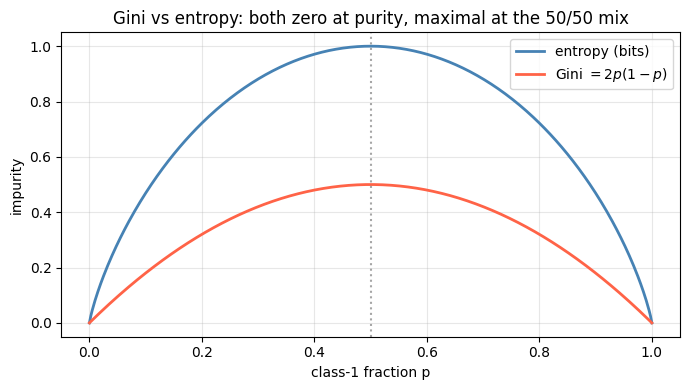

gini:  pure=0.00  balanced=0.500  4-class=0.750


train accuracy   gini=1.000   entropy=1.000


In [13]:
\
from dgs.decision_tree import gini
p = np.linspace(1e-6, 1-1e-6, 400)
H = -p*np.log2(p) - (1-p)*np.log2(1-p)
G = 2*p*(1-p)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, H, label='entropy (bits)', color='steelblue', lw=2)
ax.plot(p, G, label='Gini $= 2p(1-p)$', color='tomato', lw=2)
ax.axvline(0.5, ls=':', color='gray', alpha=0.7)
ax.set_xlabel('class-1 fraction p'); ax.set_ylabel('impurity')
ax.set_title('Gini vs entropy: both zero at purity, maximal at the 50/50 mix')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("gini:  pure=%.2f  balanced=%.3f  4-class=%.3f"
      % (gini([1,1,1]), gini([0,0,1,1]), gini([0,1,2,3])))

rng = np.random.default_rng(4)
Xg = rng.standard_normal((240, 2)); yg = (Xg[:,0] + Xg[:,1] > 0).astype(int)
tg = DecisionTree(min_samples_split=1, criterion='gini').fit(Xg, yg)
te = DecisionTree(min_samples_split=1, criterion='entropy').fit(Xg, yg)
print("train accuracy   gini=%.3f   entropy=%.3f"
      % (accuracy(yg, tg.predict(Xg)), accuracy(yg, te.predict(Xg))))


\
---
## §9  Out-of-bag error — validation for free

Each tree trains on a bootstrap resample that, on average, omits $1/e\approx37\%$ of the data.
Score every point using only the trees that never saw it and you get an **out-of-bag (OOB)**
estimate of generalization — with no held-out set at all. Set `oob_score=True` and watch
`oob_score_` climb and settle right onto the true test accuracy as the forest grows.


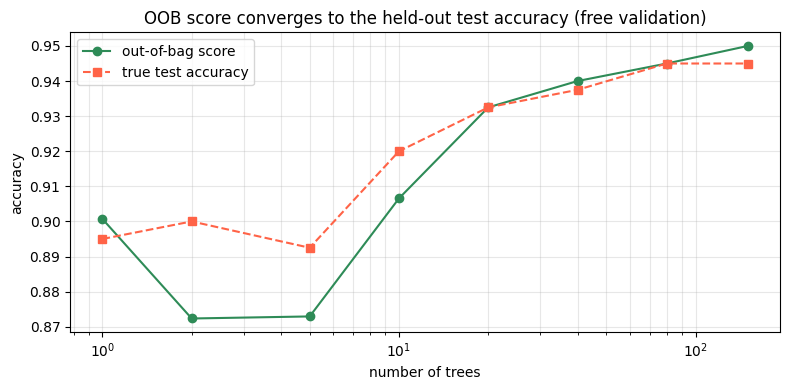

avg out-of-bag fraction per tree = 0.367  (~1/e = 0.368)
final:  OOB=0.950   test=0.945


In [14]:
\
def blob(n, seed):
    r = np.random.default_rng(seed)
    X = r.standard_normal((n, 4)); y = (X[:,0]**2 + X[:,1]**2 < 1.5).astype(int)
    return X, y
Xtr, ytr = blob(400, 1); Xte, yte = blob(400, 2)

ns, oob, test = [1, 2, 5, 10, 20, 40, 80, 150], [], []
for ne in ns:
    rf = RandomForest(n_estimators=ne, max_depth=6, max_features='sqrt',
                      criterion='gini', random_state=3, oob_score=True).fit(Xtr, ytr)
    oob.append(rf.oob_score_); test.append(accuracy(yte, rf.predict(Xte)))
frac = np.mean([len(o) for o in rf.oob_indices_]) / len(ytr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, oob, 'o-', color='seagreen', label='out-of-bag score')
ax.plot(ns, test, 's--', color='tomato', label='true test accuracy')
ax.set_xscale('log'); ax.set_xlabel('number of trees'); ax.set_ylabel('accuracy')
ax.set_title('OOB score converges to the held-out test accuracy (free validation)')
ax.legend(); ax.grid(alpha=0.3, which='both'); plt.tight_layout(); plt.show()
print("avg out-of-bag fraction per tree = %.3f  (~1/e = 0.368)" % frac)
print("final:  OOB=%.3f   test=%.3f" % (oob[-1], test[-1]))
